# Architecture Cost Modeling — Feeder Link vs ISL Scenario

## 1. Setup

In [43]:
import math
from sec_lib import (
    InputModule, OutputModule, ProcessingModule,
    Architecture, build_architecture,
    SimpleTask, SplittingTask, MergingTask,
    Algorithm, run_algorithm,
    mapping_cost, routing_cost, total_cost,
    processing_time_cost, processing_energy_cost,
)


## 1. Scenario: On-Board vs ISL Downlink

Two architectures are compared for a single-task observation pipeline:

| Architecture | Processing | Output link | Link length |
|---|---|---|---|
| **Arch A** | OBDH | Feeder Link (ground station) | 800 km |
| **Arch B** | OBDH | ISL (nearby satellite) | 200 km |

Both architectures run the same single-task algorithm that compresses the raw
image data before downlinking. The only difference is where the data ends up
and the length of the outgoing link.

In [44]:
# ── Architectures ─────────────────────────────────────────────────────────────

config_A = {
    "OBDH":       {"ew": 1e-8,  "eup": 5,  "speed": 10e6},           # ProcessingModule
    "FeederLink": {"energy": 10, "speed": 10e6, "link_length": 800}, # OutputModule
}

config_B = {
    "OBDH":       {"ew": 1e-8,  "eup": 5,  "speed": 10e6},                # ProcessingModule (same)
    "ISL":  {"energy": 10, "speed": 500e6, "link_length": 100},       # OutputModule
}

arch_A = build_architecture(config_A)
arch_B = build_architecture(config_B)

print("Architecture A:", {n: type(m).__name__ for n, m in arch_A.modules.items()})
print("Architecture B:", {n: type(m).__name__ for n, m in arch_B.modules.items()})

Architecture A: {'OBDH': 'ProcessingModule', 'FeederLink': 'OutputModule'}
Architecture B: {'OBDH': 'ProcessingModule', 'ISL': 'OutputModule'}


In [45]:
# ── Algorithm: single compression task ────────────────────────────────────────
# phi = 0.1  →  compression reduces data to 10% of input size
# n_op ~ proportional to input data size

compress_task = SimpleTask(name="compress", phi=0.9, n_op=lambda d: d)

algo_scenario = Algorithm()
algo_scenario.add(compress_task)
# no edges needed for a single-task algorithm

d_start_scenario = 100_000_000  # 500 MB raw image in bits

algo_scenario = run_algorithm(algo_scenario, d_start_scenario)

d_in_compress  = d_start_scenario
d_out_compress = d_in_compress * compress_task.phi  # terminal task: no outgoing edge in data_sizes

print(f"d_in  compress : {d_in_compress:.3e} bits")
print(f"d_out compress : {d_out_compress:.3e} bits")
print(f"workload       : {algo_scenario.workloads['compress']:.3e} ops")

d_in  compress : 1.000e+08 bits
d_out compress : 9.000e+07 bits
workload       : 1.000e+08 ops


In [46]:
# ── Mapping ────────────────────────────────────────────────────────────────────
# Same OBDH specs in both architectures → identical mapping cost

obdh_A = arch_A["OBDH"]
obdh_B = arch_B["OBDH"]

mapping_A = {"compress": (obdh_A, d_in_compress, algo_scenario.workloads["compress"])}
mapping_B = {"compress": (obdh_B, d_in_compress, algo_scenario.workloads["compress"])}

# ── Routing ────────────────────────────────────────────────────────────────────
# Data flows out of OBDH through the output module.
# The routed data size is the *compressed* output (d_out), as that is what
# gets transmitted over the link.

feeder = arch_A["FeederLink"]
isl    = arch_B["ISL"]

routing_A = {("compress", "sink"): (feeder, d_out_compress)}
routing_B = {("compress", "sink"): (isl,    d_out_compress)}

# ── Costs ──────────────────────────────────────────────────────────────────────
time_A,   energy_A   = total_cost(mapping_A, routing_A)
time_B,   energy_B   = total_cost(mapping_B, routing_B)

map_t_A,  map_e_A    = mapping_cost(mapping_A)
rout_t_A, rout_e_A   = routing_cost(routing_A)
map_t_B,  map_e_B    = mapping_cost(mapping_B)
rout_t_B, rout_e_B   = routing_cost(routing_B)

print(f"{'':30s}  {'Arch A (FL)':>14s}  {'Arch B (ISL)':>14s}")
print(f"{'─'*60}")
print(f"{'Mapping   time  (s)':30s}  {map_t_A:>14.4f}  {map_t_B:>14.4f}")
print(f"{'Mapping   energy (J)':30s}  {map_e_A:>14.4f}  {map_e_B:>14.4f}")
print(f"{'Routing   time  (s)':30s}  {rout_t_A:>14.4f}  {rout_t_B:>14.4f}")
print(f"{'Routing   energy (J)':30s}  {rout_e_A:>14.6f}  {rout_e_B:>14.6f}")
print(f"{'─'*60}")
print(f"{'TOTAL     time  (s)':30s}  {time_A:>14.4f}  {time_B:>14.4f}")
print(f"{'TOTAL     energy (J)':30s}  {energy_A:>14.4f}  {energy_B:>14.4f}")

                                   Arch A (FL)    Arch B (ISL)
────────────────────────────────────────────────────────────
Mapping   time  (s)                    10.0000         10.0000
Mapping   energy (J)                   51.0000         51.0000
Routing   time  (s)                     9.0000          0.1800
Routing   energy (J)                261.278099        3.600000
────────────────────────────────────────────────────────────
TOTAL     time  (s)                    19.0000         10.1800
TOTAL     energy (J)                  312.2781         54.6000


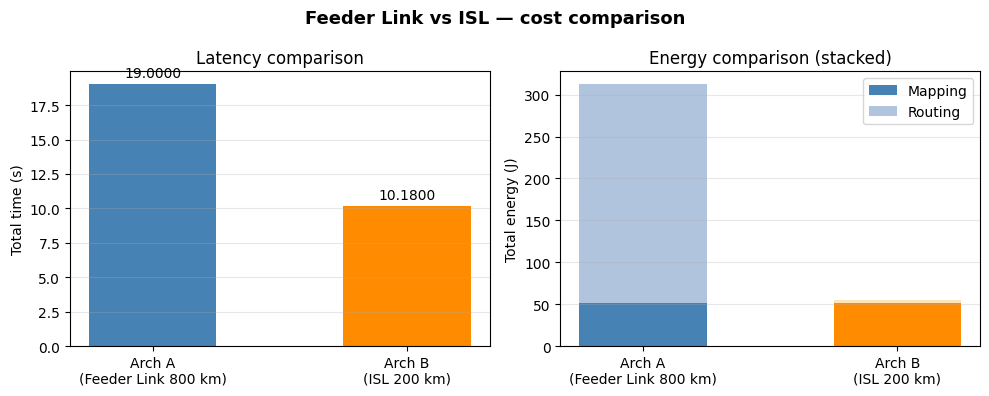

Saved scenario_comparison.png


In [47]:
# ── Bar chart comparison ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

labels   = ["Arch A\n(Feeder Link 800 km)", "Arch B\n(ISL 200 km)"]
times    = [time_A,   time_B]
energies = [energy_A, energy_B]

x   = np.arange(len(labels))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# — time —
bars1 = ax1.bar(x, times, color=["steelblue", "darkorange"], width=0.5)
ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1.set_ylabel("Total time (s)")
ax1.set_title("Latency comparison")
ax1.bar_label(bars1, fmt="%.4f", padding=3)
ax1.grid(axis="y", alpha=0.3)

# stacked breakdown: mapping vs routing
map_e  = [map_e_A,  map_e_B]
rout_e = [rout_e_A, rout_e_B]
bars_m = ax2.bar(x, map_e,  label="Mapping",  color=["steelblue",  "darkorange"],  width=0.5)
bars_r = ax2.bar(x, rout_e, label="Routing",  color=["lightsteelblue", "moccasin"], width=0.5,
                  bottom=map_e)
ax2.set_xticks(x); ax2.set_xticklabels(labels)
ax2.set_ylabel("Total energy (J)")
ax2.set_title("Energy comparison (stacked)")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

plt.suptitle("Feeder Link vs ISL — cost comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("scenario_comparison.png", dpi=120)
plt.show()
print("Saved scenario_comparison.png")

## 2. Space Exploration: ISL Speed Sweep

The ISL output module speed is swept across a range of values.
Three curves are compared on each plot:

| Curve | OBDH processing | ISL speed |
|---|---|---|
| **Base (fixed ISL)** | ✓ | fixed at scenario value |
| **With computing** | ✓ | variable |
| **Without computing** | ✗ | variable |

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# ── Sweep parameters ──────────────────────────────────────────────────────────
isl_speeds = np.linspace(10e6, 100e6, 200)   # 1 Mbit/s → 1 Gbit/s

obdh = arch_B["OBDH"]
isl_fixed = arch_B["ISL"]   # fixed reference point

# Precompute quantities that don't change across the sweep
d_in   = d_in_compress
d_out  = d_out_compress
n_op   = algo_scenario.workloads["compress"]

map_t_fixed,  map_e_fixed  = mapping_cost({"compress": (obdh, d_in, n_op)})
rout_t_fixed, rout_e_fixed = routing_cost({("compress", "sink"): (isl_fixed, d_out)})
base_time   = np.full(200,time_A)
base_energy = np.full(200, energy_A)

# ── With computing: OBDH + variable ISL ───────────────────────────────────────
with_t, with_e = [], []
for s in isl_speeds:
    isl_var = OutputModule(energy=isl_fixed.energy, speed=s, link_length=isl_fixed.link_length)
    rt, re = routing_cost({("compress", "sink"): (isl_var, d_out)})
    with_t.append(map_t_fixed + rt)
    with_e.append(map_e_fixed + re)

# ── Without computing: no OBDH, raw data sent directly over variable ISL ──────
without_t, without_e = [], []
for s in isl_speeds:
    isl_var = OutputModule(energy=isl_fixed.energy, speed=s, link_length=isl_fixed.link_length)
    rt, re = routing_cost({("compress", "sink"): (isl_var, d_in)})   # d_in: uncompressed
    without_t.append(rt)
    without_e.append(re)

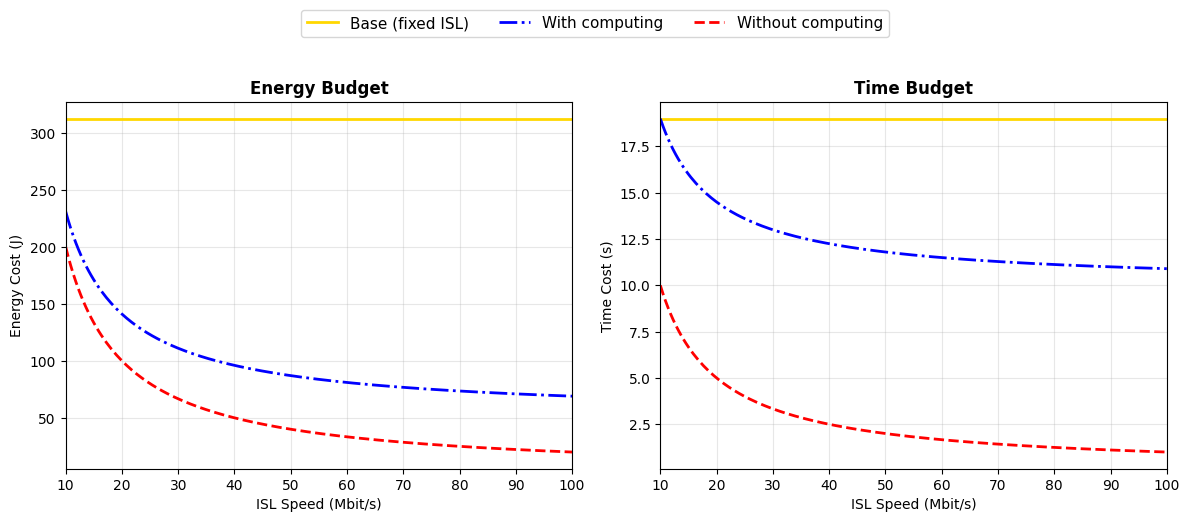

Saved isl_sweep.png


In [49]:
isl_mbps = isl_speeds / 1e6   # convert to Mbit/s for readability

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ── Energy ────────────────────────────────────────────────────────────────────
ax1.plot(isl_mbps, base_energy,   label="Base (fixed ISL)",    linewidth=2, color="gold",   linestyle="-")
ax1.plot(isl_mbps, with_e,        label="With computing",      linewidth=2, color="blue",   linestyle="-.")
ax1.plot(isl_mbps, without_e,     label="Without computing",   linewidth=2, color="red",    linestyle="--")
ax1.set_xlabel("ISL Speed (Mbit/s)")
ax1.set_ylabel("Energy Cost (J)")
ax1.set_title("Energy Budget", fontweight="bold")
ax1.set_xlim(isl_mbps[0], isl_mbps[-1])
ax1.grid(True, alpha=0.3)

# ── Time ──────────────────────────────────────────────────────────────────────
ax2.plot(isl_mbps, base_time,     label="Base (fixed ISL)",    linewidth=2, color="gold",   linestyle="-")
ax2.plot(isl_mbps, with_t,        label="With computing",      linewidth=2, color="blue",   linestyle="-.")
ax2.plot(isl_mbps, without_t,     label="Without computing",   linewidth=2, color="red",    linestyle="--")
ax2.set_xlabel("ISL Speed (Mbit/s)")
ax2.set_ylabel("Time Cost (s)")
ax2.set_title("Time Budget", fontweight="bold")
ax2.set_xlim(isl_mbps[0], isl_mbps[-1])
ax2.grid(True, alpha=0.3)

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.05), ncol=3, fontsize=11)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.savefig("isl_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved isl_sweep.png")